## Multiple Linear Regression, the Hard Way (PyTorch version)

### Goals

- Extend our understanding of the linear regression model to multiple features

We're going to do the house-price-prediction example, but doing the linear regression part by hand, like we did last week with the single-feature case.

### Course Objectives Addressed

This notebook addresses the following CS 375 course objectives:

- TM-LinearLayers: "I can implement linear (fully-connected) layers using efficient parallel code."
- TM-TensorOps: "I can reason about matrix multiplication and multi-dimensional tensor shapes."
- TM-DataFlow: "I can draw clear diagrams of the data flow through a neural network, labeling each layer and the tensor shapes at each step."
- TM-Autograd: "I can explain the purpose of automatic differentiation and identify how it is used in PyTorch code."

This PyTorch version of the multi-input linear regression notebook introduces `requires_grad` and optimizers, giving you a first look at how PyTorch's automatic differentiation enables parameter optimization.

## Setup

Let's import necessary modules: *pandas* and NumPy for data wrangling, Matplotlib for plotting, PyTorch for the optimization, and some sklearn utilities. We'll be implementing the linear regression model ourselves using PyTorch and the LBFGS optimizer.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import torch
import torch.optim as optim

We'll load the data as before.

In [ ]:
ames = pd.read_csv('https://github.com/kcarnold/AmesHousing/blob/master/data/ames.csv.gz?raw=true', compression="gzip")
ames['price'] = ames["Sale_Price"] / 100_000 # Make `price` be in units of $100k, to be easier to interpret.


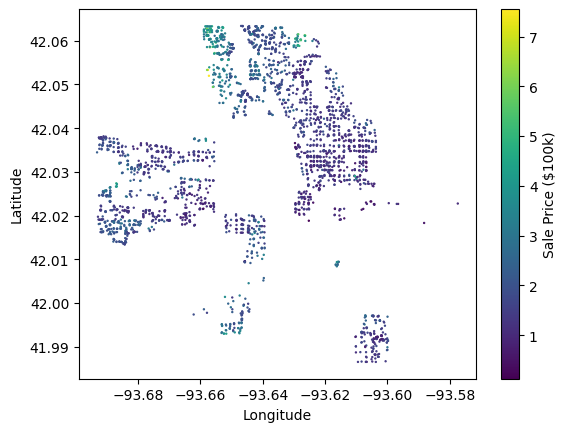

In [ ]:
def plot_data():
    # You don't have to know how this function works.
    plt.scatter(ames['Longitude'], ames['Latitude'], c=ames["price"], s=.5)
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.colorbar(label="Sale Price ($100k)")
plot_data()

We'll use location (longitude and latitude) to predict price.

In [ ]:
feature_names = ['Longitude', 'Latitude']
X = torch.tensor(ames[feature_names].values).float()
X.shape

torch.Size([2930, 2])

Our target, called `y` by convention, will be the home price (we'll soon introduce a different *y*, but start with this one).

In [ ]:
y = torch.tensor(ames['price'].values).float()
y.shape

torch.Size([2930])

Notice that `X` has two axes and thus is written in uppercase; `y` has 1 and thus is written in lowercase. (This is `sklearn` convention; other libraries are less consistent about this.)

Now let's split the data into a `train` and `valid` set (which sklearn calls train-*test*, but that's fine). `random_state` is how `sklearn` specifies the random seed (it's actually slightly more flexible than a seed).

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=.2, random_state=42)

We'll verify that the shapes make sense. Note how many items are in each of the sets.

In [ ]:
X_train.shape, y_train.shape

(torch.Size([2344, 2]), torch.Size([2344]))

In [ ]:
X_valid.shape, y_valid.shape

(torch.Size([586, 2]), torch.Size([586]))

Here's a function to plot our regression model in "data space" (i.e., what it would predict everywhere on the map).

This function is pretty customized to our specific use case, though you can get inspiration from it for use in other situations.

In [ ]:
def plot_model(prediction_fn, fig=None, prediction_args=()):
    # Compute extents
    lat_min = ames.Latitude.min()
    lat_max = ames.Latitude.max()
    lon_min = ames.Longitude.min()
    lon_max = ames.Longitude.max()
    price_min = ames.price.min()
    price_max = ames.price.max()

    # Ask the classifier for predictions on a grid
    xx, yy = np.meshgrid(np.linspace(lon_min, lon_max, 250), np.linspace(lat_min, lat_max, 250))
    Z = prediction_fn(np.c_[xx.ravel(), yy.ravel()], *prediction_args).reshape(xx.shape)

    if fig is None:
        fig = plt.figure(figsize=plt.figaspect(2))

    # Left side: show the predictions in 2D. Superimpose the original data.
    ax = fig.add_subplot(2, 1, 1)
    surf = ax.contourf(xx, yy, Z, alpha=.5, cmap=plt.cm.viridis, vmin=price_min, vmax=price_max)
    ax.scatter(ames['Longitude'], ames['Latitude'], c=ames["price"], s=1, cmap='viridis', vmin=price_min, vmax=price_max)
    ax.set(xlabel="Longitude", ylabel="Latitude", title="2D contour view")
    fig.colorbar(surf, label="Sale Price ($100k)")

    # Right side: show the predictions in 3D
    ax = fig.add_subplot(2, 1, 2, projection='3d')
    ax.plot_surface(xx, yy, Z, alpha=.5, cmap=plt.cm.viridis, vmin=price_min, vmax=price_max)
    #ax.scatter(ames['Longitude'], ames['Latitude'], c=ames["price"], s=1, cmap='viridis', vmin=price_min, vmax=price_max)
    ax.set(title="3D view")

## Task

### Part A: Linear regression

Step A1: **Fit a linear regression model to the training set (`X_train`, `y_train`).**

Last time you did this, you used `sklearn`. This time, you'll do it using PyTorch and the LBFGS optimizer. You'll need to calculate the coefficients `w` and `b` that minimize the mean squared error (MSE) between the model's predictions and the actual values.

I'll walk you through this. First, we'll work on making a single prediction. To do that, we'll need some `weights` and a `bias`, which we'll initialize randomly as PyTorch tensors. **Think about what shape these should be.**

In [ ]:
torch.manual_seed(42)

weights = torch.randn(..., requires_grad=True)
bias = torch.randn(1, requires_grad=True)
weights, bias

(tensor([0.3367, 0.1288], requires_grad=True),
 tensor([0.2345], requires_grad=True))

Now we'll make a single prediction. Think about how you can do this using a dot product.

In [ ]:
x_i = X_train[0]
y_pred_i = ...
y_pred_i

tensor([-25.8750], grad_fn=<AddBackward0>)

Next we'll make a prediction for every item in the training set. Think about how you can do this using a dot product.

In [ ]:
def linreg_forward(X, weights, bias):
    return X @ weights + bias

y_pred_train = linreg_forward(X_train, weights, bias)
y_pred_train.shape

torch.Size([2344])

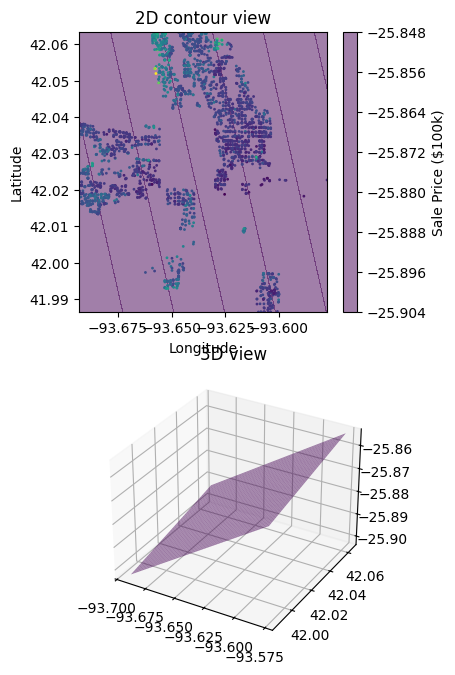

In [ ]:
plot_model(lambda X: linreg_forward(torch.tensor(X).float(), weights, bias).detach().numpy())

Now let's compute the loss and optimize it, as before.

In [ ]:
def compute_mse_loss(y_true, y_pred):
    return ...

mse_loss = compute_mse_loss(..., ...)
print("MSE loss:", mse_loss.item())

MSE loss: 765.9743041992188


Now we'll use the LBFGS optimizer from PyTorch to find the best parameters. LBFGS is a quasi-Newton optimization algorithm that is particularly effective for small to medium sized problems.

In [ ]:
# Reset the parameters
torch.manual_seed(42)
weights = torch.randn(2, requires_grad=True)
bias = torch.randn(1, requires_grad=True)

# Create LBFGS optimizer
optimizer = optim.LBFGS([weights, bias], lr=1, max_iter=20)

def closure():
    optimizer.zero_grad()
    y_pred = linreg_forward(X_train, weights, bias)
    loss = compute_mse_loss(y_train, y_pred)
    loss.backward()
    return loss

# Optimize
loss = optimizer.step(closure)
print("Final loss:", loss.item())

Final loss: 765.9743041992188


In [ ]:
print("Fitted weights:", weights.detach().numpy())
print("Fitted bias:", bias.detach().numpy())

Fitted weights: [0.09082168 0.23917523]
Fitted bias: [0.23708798]


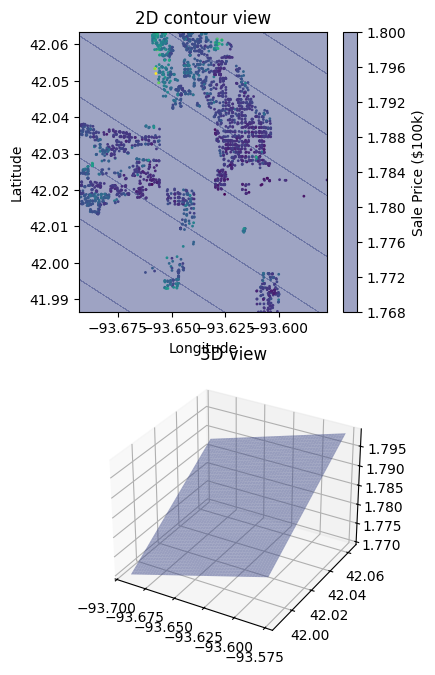

In [ ]:
plot_model(lambda X: linreg_forward(torch.FloatTensor(X), weights, bias).detach().numpy())

## Analysis

1. What are the shapes of `X`, `y`, `w`, and `b`? Explain why each has the shape it does.

2. Suppose we were trying to predict the original, un-scaled sale price. (i.e., all of our predictions need to be multiplied by 100,000.) Could you adjust the model that we just trained to do that *without* needing to call `minimize` again? If so, how? If not, why not?

*your thoughtful answers here*